# Sub-clustering do Cluster 0

Este notebook foca-se **apenas na análise interna do Cluster 0** do clustering principal.

O objetivo é perceber se o Cluster 0, por ser muito grande, contém subgrupos com perfis de financiamento diferentes.

**Importante:** o Cluster 0 é reconstruído da mesma forma que no notebook principal:  
1. limpeza e criação das features de funding;  
2. `RobustScaler`;  
3. PCA com 3 componentes;  
4. K-Means com `K=4`;  
5. seleção das empresas com `Cluster == 0`;  
6. sub-clustering apenas dentro desse grupo.

A interpretação final usa `K=3` para o sub-clustering, porque dá uma segmentação simples e fácil de explicar.

In [1]:
# ============================================================
# 0. Imports and settings
# ============================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = "investments_VC.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "/mnt/data/investments_VC.csv"

print(f"Using data file: {DATA_PATH}")

Using data file: /mnt/data/investments_VC.csv


## 1. Recriar as features usadas no clustering principal

Esta secção é só a preparação necessária para chegar ao mesmo Cluster 0 usado antes.  
Não é uma nova análise do clustering principal.

In [2]:
# ============================================================
# 1. Data preparation: same logic as the main notebook
# ============================================================
raw = pd.read_csv(DATA_PATH, encoding="latin1")
df = raw.copy()

# Remove columns that are not useful for the clustering logic
irrelevant_col = [
    'permalink', 'homepage_url', 'state_code', 'region',
    'founded_month', 'founded_quarter', 'founded_year'
]
df.drop(columns=irrelevant_col, inplace=True, errors='ignore')
df.dropna(how='all', inplace=True)

# Create stage_level from the highest round reached
round_cols = ['round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']
stage_level = np.zeros(len(df), dtype=int)
for level, col in enumerate(round_cols, start=1):
    if col in df.columns:
        stage_level = np.where(df[col].to_numpy() > 0, level, stage_level)

df['stage_level'] = stage_level
df.drop(columns=[c for c in round_cols if c in df.columns], inplace=True, errors='ignore')

# Drop columns with too many zeros or missing values
ZERO_THRESHOLD = 0.98
NULL_THRESHOLD = 0.90

zero_ratio = (df == 0).sum() / len(df)
null_ratio = df.isnull().sum() / len(df)
cols_to_drop = list(set(
    zero_ratio[zero_ratio > ZERO_THRESHOLD].index.tolist() +
    null_ratio[null_ratio > NULL_THRESHOLD].index.tolist()
))
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Clean funding_total_usd column, which has spaces in the original CSV
if ' funding_total_usd ' in df.columns:
    df[' funding_total_usd '] = df[' funding_total_usd '].str.replace(',', '', regex=False)
    df[' funding_total_usd '] = pd.to_numeric(df[' funding_total_usd '], errors='coerce')

# Basic cleaning
if 'status' in df.columns:
    df['status'] = df['status'].astype('category')

df.dropna(subset=['name'], inplace=True)
df.drop_duplicates(inplace=True)
df.columns = df.columns.str.strip()
df.dropna(subset=['funding_total_usd', 'market'], inplace=True)

# Remove companies where all main funding types are zero
funding_cols = ['seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity']
df = df[~(df[funding_cols] == 0).all(axis=1)].copy()

# Combine seed, angel and grant into early-stage funding
df['early_stage_funding'] = df['seed'] + df['angel'] + df['grant']
df.drop(columns=['seed', 'angel', 'grant'], inplace=True, errors='ignore')

# Funding source ratios
funding_type_cols = ['early_stage_funding', 'venture', 'debt_financing', 'private_equity']
total_funding_safe = df['funding_total_usd'].replace(0, np.nan)

for col in funding_type_cols:
    df[f'{col}_ratio'] = df[col] / total_funding_safe

ratio_cols = [f'{col}_ratio' for col in funding_type_cols]
df[ratio_cols] = df[ratio_cols].fillna(0).clip(lower=0, upper=1)

# Log-transform skewed monetary/count features
columns_to_log = [
    'funding_total_usd',
    'funding_rounds',
    'early_stage_funding',
    'venture',
    'debt_financing',
    'private_equity'
]

for col in columns_to_log:
    df[f'log_{col}'] = np.log1p(df[col])

features_to_scale = [
    'log_funding_total_usd',
    'log_funding_rounds',
    'log_early_stage_funding',
    'log_venture',
    'log_debt_financing',
    'log_private_equity',
    'stage_level',
    'early_stage_funding_ratio',
    'venture_ratio',
    'debt_financing_ratio',
    'private_equity_ratio'
]

profile_cols = [
    'funding_total_usd',
    'funding_rounds',
    'early_stage_funding',
    'venture',
    'debt_financing',
    'private_equity',
    'stage_level',
    'early_stage_funding_ratio',
    'venture_ratio',
    'debt_financing_ratio',
    'private_equity_ratio'
]

info_columns = ['name', 'category_list', 'market', 'status', 'country_code', 'city']

df_clustering = df.dropna(subset=features_to_scale).copy()

scaler = RobustScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clustering[features_to_scale]),
    columns=features_to_scale,
    index=df_clustering.index
)

df_final = pd.concat([df_clustering[info_columns], df_scaled], axis=1)

print(f"Prepared dataset: {df_scaled.shape[0]:,} startups x {df_scaled.shape[1]} clustering features")
display(df_clustering[profile_cols + info_columns].head())

Prepared dataset: 36,931 startups x 11 clustering features


,funding_total_usd,funding_rounds,early_stage_funding,venture,debt_financing,private_equity,stage_level,early_stage_funding_ratio,venture_ratio,debt_financing_ratio,private_equity_ratio,name,category_list,market,status,country_code,city
0,"1,750,000.000",1.000,"1,750,000.000",0.000,0.000,0.000,0,1.000,0.000,0.000,0.000,#waywire,|Entertainment|Politics|Social Media|News|,News,acquired,USA,New York
1,"4,000,000.000",2.000,0.000,"4,000,000.000",0.000,0.000,0,0.000,1.000,0.000,0.000,&TV Communications,|Games|,Games,operating,USA,Los Angeles
2,"40,000.000",1.000,"40,000.000",0.000,0.000,0.000,0,1.000,0.000,0.000,0.000,'Rock' Your Paper,|Publishing|Education|,Publishing,operating,EST,Tallinn
3,"1,500,000.000",1.000,"1,500,000.000",0.000,0.000,0.000,0,1.000,0.000,0.000,0.000,(In)Touch Network,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,operating,GBR,London
5,"7,000,000.000",1.000,0.000,"7,000,000.000",0.000,0.000,2,0.000,1.000,0.000,0.000,.Club Domains,|Software|,Software,NaN,USA,Oakland Park


## 2. Recriar o Cluster 0 do clustering principal

Aqui só recriamos os labels principais para conseguir isolar o Cluster 0.  
A análise visual e descritiva começa apenas depois disso.

In [3]:
# ============================================================
# 2. Recreate the main PCA-based K-Means clustering
# ============================================================
MAIN_K = 4

pca_main = PCA(n_components=3)
df_pca = pd.DataFrame(
    pca_main.fit_transform(df_scaled),
    columns=['PC1', 'PC2', 'PC3'],
    index=df_scaled.index
)

main_kmeans = KMeans(
    n_clusters=MAIN_K,
    init='k-means++',
    random_state=RANDOM_STATE,
    n_init=10
)

df_final['Cluster'] = main_kmeans.fit_predict(df_pca)

print(f"PCA variance explained by 3 components: {pca_main.explained_variance_ratio_.sum():.2%}")
print("Main cluster distribution:")
display(df_final['Cluster'].value_counts().sort_index().rename('n').to_frame())

PCA variance explained by 3 components: 95.78%
Main cluster distribution:


,n
Cluster,
0,24102
1,3819
2,1305
3,7705


In [4]:
# ============================================================
# 3. Select only Cluster 0
# ============================================================
cluster0_mask = df_final['Cluster'] == 0

df_scaled_c0 = df_scaled.loc[cluster0_mask].copy()
df_final_c0 = df_final.loc[cluster0_mask].copy()
df_clustering_c0 = df_clustering.loc[cluster0_mask].copy()

print(f"Cluster 0 subset: {df_scaled_c0.shape[0]:,} startups x {df_scaled_c0.shape[1]} features")
print("Share of full clustering dataset:", f"{len(df_scaled_c0) / len(df_scaled):.1%}")

Cluster 0 subset: 24,102 startups x 11 features
Share of full clustering dataset: 65.3%


## 3. Escolha do número de subclusters

O `K=3` não é escolhido por ser obrigatoriamente o melhor valor matemático, mas porque dá uma leitura de negócio clara:

1. empresas early-stage com mais rondas;  
2. empresas pequenas/early-stage com venture capital;  
3. empresas seed-stage pequenas e simples.

Mesmo assim, validamos a escolha com inertia e silhouette.

,K,Inertia,Silhouette_sample,Cluster_sizes
0,2,"20,487.398",0.525,"{0: 11485, 1: 12617}"
1,3,"15,317.551",0.505,"{0: 4114, 1: 10902, 2: 9086}"
2,4,"12,322.866",0.479,"{0: 9030, 1: 8650, 2: 3459, 3: 2963}"
3,5,"10,264.747",0.467,"{0: 3321, 1: 8627, 2: 4209, 3: 4989, 4: 2956}"
4,6,"8,354.226",0.474,"{0: 6008, 1: 3321, 2: 4203, 3: 2626, 4: 4989, ..."
5,7,"7,116.327",0.474,"{0: 4712, 1: 4142, 2: 2692, 3: 3210, 4: 4426, ..."
6,8,"5,852.778",0.509,"{0: 4153, 1: 1694, 2: 1294, 3: 4985, 4: 2660, ..."
7,9,"5,136.924",0.517,"{0: 3441, 1: 4982, 2: 1189, 3: 1071, 4: 2660, ..."


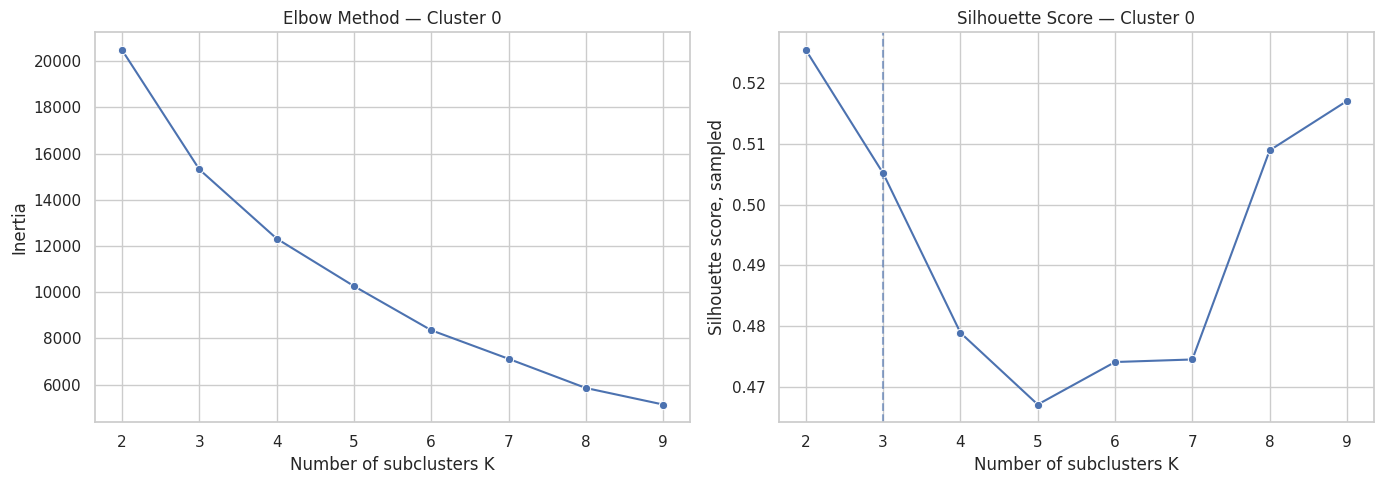

In [5]:
# ============================================================
# 4. Elbow and Silhouette for sub-clustering Cluster 0
# ============================================================
K_range_c0 = range(2, 10)
inertia_c0 = []
silhouette_c0 = []
size_dicts = []

for k in K_range_c0:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = km.fit_predict(df_scaled_c0)
    inertia_c0.append(km.inertia_)
    silhouette_c0.append(
        silhouette_score(
            df_scaled_c0,
            labels,
            sample_size=min(5000, len(df_scaled_c0)),
            random_state=RANDOM_STATE
        )
    )
    size_dicts.append(pd.Series(labels).value_counts().sort_index().to_dict())

k_eval_c0 = pd.DataFrame({
    'K': list(K_range_c0),
    'Inertia': inertia_c0,
    'Silhouette_sample': silhouette_c0,
    'Cluster_sizes': [str(x) for x in size_dicts]
})

display(k_eval_c0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=k_eval_c0, x='K', y='Inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow Method — Cluster 0')
axes[0].set_xlabel('Number of subclusters K')
axes[0].set_ylabel('Inertia')

sns.lineplot(data=k_eval_c0, x='K', y='Silhouette_sample', marker='o', ax=axes[1])
axes[1].axvline(3, linestyle='--', alpha=0.6)
axes[1].set_title('Silhouette Score — Cluster 0')
axes[1].set_xlabel('Number of subclusters K')
axes[1].set_ylabel('Silhouette score, sampled')

plt.tight_layout()
plt.show()

## 4. Sub-clustering final com K=3

`K=3` é usado por interpretabilidade.  
A partir daqui, cada empresa dentro do Cluster 0 recebe um `SubCluster` e um nome interpretativo.

In [6]:
# ============================================================
# 5. Final sub-clustering with K=3
# ============================================================
SUB_K = 3

kmeans_c0 = KMeans(
    n_clusters=SUB_K,
    init='k-means++',
    random_state=RANDOM_STATE,
    n_init=10
)

sub_labels = kmeans_c0.fit_predict(df_scaled_c0)

df_final_c0['SubCluster'] = sub_labels
df_clustering_c0['SubCluster'] = sub_labels

sil_k3 = silhouette_score(
    df_scaled_c0,
    sub_labels,
    sample_size=min(10000, len(df_scaled_c0)),
    random_state=RANDOM_STATE
)

subcluster_sizes = df_final_c0['SubCluster'].value_counts().sort_index().rename('n').to_frame()
subcluster_sizes['pct_cluster0'] = subcluster_sizes['n'] / len(df_final_c0) * 100

print(f"Sub-clustering complete with K={SUB_K}")
print(f"Silhouette score, sampled: {sil_k3:.4f}")
display(subcluster_sizes)

Sub-clustering complete with K=3
Silhouette score, sampled: 0.5011


,n,pct_cluster0
SubCluster,,
0,4114,17.069
1,10902,45.233
2,9086,37.698


In [7]:
# ============================================================
# 6. Give business names to subclusters dynamically
# ============================================================
median_profile_tmp = df_clustering_c0.groupby('SubCluster')[profile_cols].median()
nonzero_tmp = df_clustering_c0.groupby('SubCluster')[profile_cols].apply(lambda x: (x > 0).mean())

# VC-backed group: highest median venture_ratio / strongest venture presence
vc_cluster = median_profile_tmp['venture_ratio'].idxmax()

remaining_clusters = [c for c in median_profile_tmp.index if c != vc_cluster]

# Among non-VC clusters, the one with higher funding rounds / funding total is the multi-round early-stage group
multi_early_cluster = median_profile_tmp.loc[remaining_clusters].sort_values(
    ['funding_rounds', 'funding_total_usd'], ascending=False
).index[0]

small_seed_cluster = [c for c in remaining_clusters if c != multi_early_cluster][0]

subcluster_name_map = {
    multi_early_cluster: 'Early-stage multi-round',
    vc_cluster: 'Small / early venture-backed',
    small_seed_cluster: 'Small seed-stage'
}

df_final_c0['SubCluster_Name'] = df_final_c0['SubCluster'].map(subcluster_name_map)
df_clustering_c0['SubCluster_Name'] = df_clustering_c0['SubCluster'].map(subcluster_name_map)

subcluster_labels = (
    df_final_c0[['SubCluster', 'SubCluster_Name']]
    .drop_duplicates()
    .sort_values('SubCluster')
    .reset_index(drop=True)
)

display(subcluster_labels)

,SubCluster,SubCluster_Name
0,0,Early-stage multi-round
1,1,Small / early venture-backed
2,2,Small seed-stage


## 5. Tamanho de cada subcluster

Esta visualização mostra quanto cada perfil pesa dentro do Cluster 0.

,SubCluster_Name,n,pct_cluster0
0,Small / early venture-backed,10902,45.233
1,Small seed-stage,9086,37.698
2,Early-stage multi-round,4114,17.069


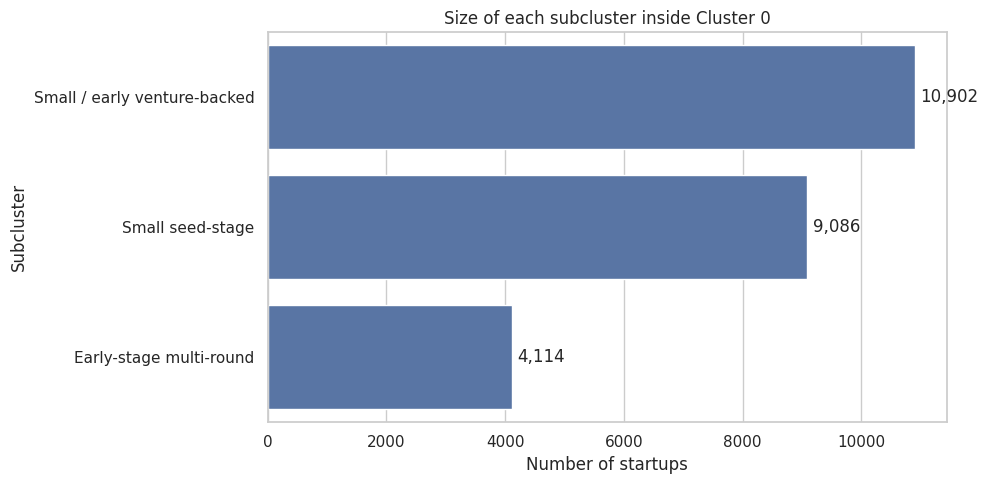

In [8]:
# ============================================================
# 7. Subcluster size visualization
# ============================================================
size_plot = (
    df_final_c0['SubCluster_Name']
    .value_counts()
    .rename_axis('SubCluster_Name')
    .reset_index(name='n')
)
size_plot['pct_cluster0'] = size_plot['n'] / len(df_final_c0) * 100
size_plot = size_plot.sort_values('n', ascending=False)

display(size_plot)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=size_plot, x='n', y='SubCluster_Name', color='#4C72B0')
ax.set_title('Size of each subcluster inside Cluster 0')
ax.set_xlabel('Number of startups')
ax.set_ylabel('Subcluster')

for container in ax.containers:
    ax.bar_label(container, labels=[f'{x:,.0f}' for x in size_plot['n']], padding=4)

plt.tight_layout()
plt.show()

## 6. Visualização PCA 2D dos subclusters

O PCA 2D é apenas uma visualização.  
A distância real usada pelo K-Means vem das 11 features escaladas, não apenas destes dois eixos.

PCA 2D explained variance inside Cluster 0:
[0.57697285 0.22577317]
Cumulative: 0.8027460199141587


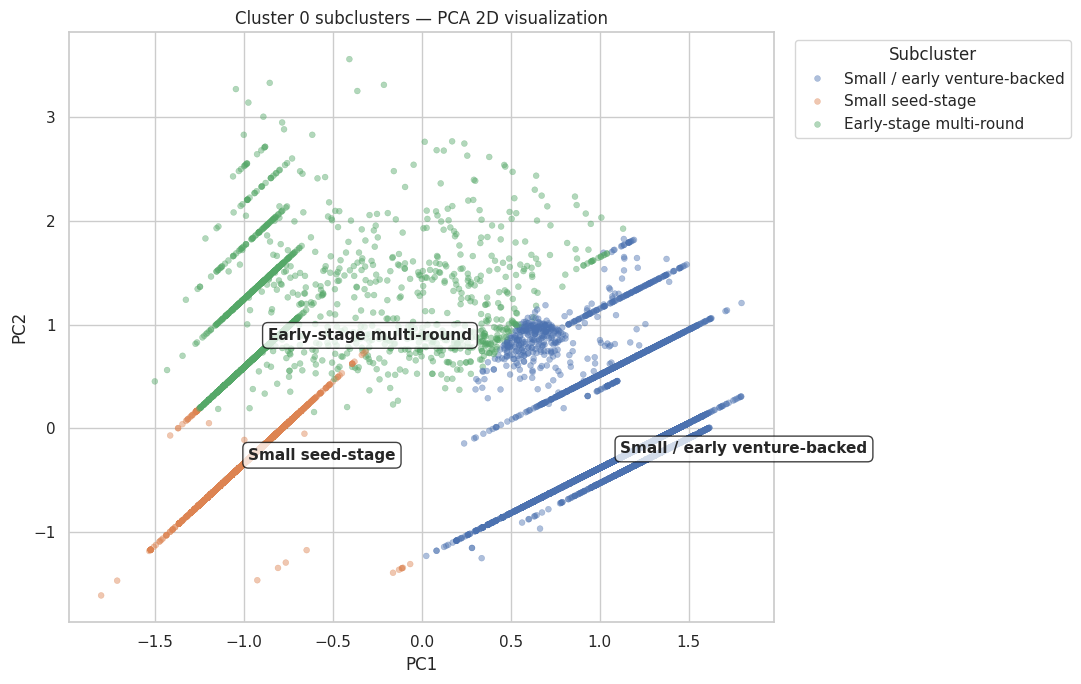

In [9]:
# ============================================================
# 8. PCA 2D visualization of subclusters
# ============================================================
pca_c0_2d = PCA(n_components=2)
pca_c0_2d_array = pca_c0_2d.fit_transform(df_scaled_c0)

pca_plot_df = pd.DataFrame(
    pca_c0_2d_array,
    columns=['PC1', 'PC2'],
    index=df_scaled_c0.index
)
pca_plot_df['SubCluster_Name'] = df_final_c0['SubCluster_Name']
pca_plot_df['SubCluster'] = df_final_c0['SubCluster']
pca_plot_df['name'] = df_final_c0['name']
pca_plot_df['market'] = df_final_c0['market']

# Sample for readability
plot_sample = pca_plot_df.sample(
    n=min(12000, len(pca_plot_df)),
    random_state=RANDOM_STATE
)

centers_2d = pca_plot_df.groupby('SubCluster_Name')[['PC1', 'PC2']].median().reset_index()

print("PCA 2D explained variance inside Cluster 0:")
print(pca_c0_2d.explained_variance_ratio_)
print("Cumulative:", pca_c0_2d.explained_variance_ratio_.sum())

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(
    data=plot_sample,
    x='PC1',
    y='PC2',
    hue='SubCluster_Name',
    alpha=0.45,
    s=18,
    edgecolor=None
)

for _, row in centers_2d.iterrows():
    ax.text(
        row['PC1'], row['PC2'], row['SubCluster_Name'],
        fontsize=11, weight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='black', alpha=0.75)
    )

ax.set_title('Cluster 0 subclusters — PCA 2D visualization')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.legend(title='Subcluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. O que distingue cada subcluster?

A tabela e o heatmap abaixo mostram o **lift** de cada feature:  

> valor médio escalado do subcluster − valor médio escalado do Cluster 0

Valores positivos indicam que esse subcluster está acima da média do Cluster 0 nessa feature.  
Valores negativos indicam que está abaixo.

,Total funding,Funding rounds,Early-stage funding,Venture funding,Debt financing,Private equity,Stage level,Early-stage ratio,Venture ratio,Debt ratio,Private equity ratio
SubCluster_Name,,,,,,,,,,,
Early-stage multi-round,-0.005,0.998,0.476,-0.248,-0.001,-0.001,-0.085,0.313,-0.340,-0.000,-0.000
Small / early venture-backed,0.350,-0.103,-0.521,0.469,-0.001,-0.001,0.146,-0.515,0.518,-0.000,-0.000
Small seed-stage,-0.418,-0.329,0.410,-0.451,0.002,0.002,-0.137,0.476,-0.468,0.000,0.000


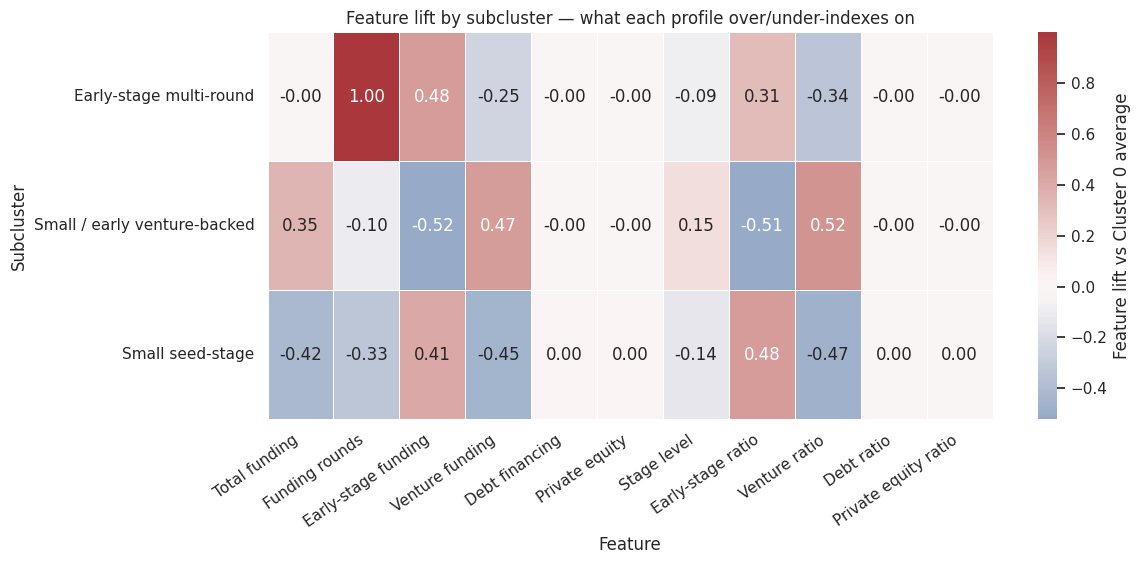

In [10]:
# ============================================================
# 9. Feature lift: what makes each subcluster different?
# ============================================================
scaled_sub = df_scaled_c0.copy()
scaled_sub['SubCluster_Name'] = df_final_c0['SubCluster_Name']

centroids = scaled_sub.groupby('SubCluster_Name')[features_to_scale].mean()
overall_c0 = df_scaled_c0[features_to_scale].mean()
lift = centroids - overall_c0

feature_labels = {
    'log_funding_total_usd': 'Total funding',
    'log_funding_rounds': 'Funding rounds',
    'log_early_stage_funding': 'Early-stage funding',
    'log_venture': 'Venture funding',
    'log_debt_financing': 'Debt financing',
    'log_private_equity': 'Private equity',
    'stage_level': 'Stage level',
    'early_stage_funding_ratio': 'Early-stage ratio',
    'venture_ratio': 'Venture ratio',
    'debt_financing_ratio': 'Debt ratio',
    'private_equity_ratio': 'Private equity ratio'
}

lift_display = lift.rename(columns=feature_labels)
display(lift_display.round(3))

plt.figure(figsize=(12, 5.8))
ax = sns.heatmap(
    lift_display,
    annot=True,
    fmt='.2f',
    center=0,
    cmap='vlag',
    linewidths=0.5,
    cbar_kws={'label': 'Feature lift vs Cluster 0 average'}
)
ax.set_title('Feature lift by subcluster — what each profile over/under-indexes on')
ax.set_xlabel('Feature')
ax.set_ylabel('Subcluster')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 8. Perfil financeiro dos subclusters

Como funding é muito enviesado por outliers, a análise usa principalmente **medianas** e **percentagem de empresas com valor > 0**.

In [11]:
# ============================================================
# 10. Financial profile: medians, means and non-zero rates
# ============================================================
median_profile = df_clustering_c0.groupby('SubCluster_Name')[profile_cols].median()
mean_profile = df_clustering_c0.groupby('SubCluster_Name')[profile_cols].mean()
nonzero_profile = df_clustering_c0.groupby('SubCluster_Name')[profile_cols].apply(lambda x: (x > 0).mean() * 100)

print("Median profile — typical startup in each subcluster")
display(median_profile.round(2).T)

print("Share of startups with non-zero value in each funding source")
display(nonzero_profile.round(1).T)

Median profile — typical startup in each subcluster


SubCluster_Name,Early-stage multi-round,Small / early venture-backed,Small seed-stage
funding_total_usd,"900,000.000","2,840,500.000","250,000.000"
funding_rounds,2.000,1.000,1.000
early_stage_funding,"653,000.000",0.000,"250,000.000"
venture,0.000,"2,750,000.000",0.000
debt_financing,0.000,0.000,0.000
private_equity,0.000,0.000,0.000
stage_level,0.000,0.000,0.000
early_stage_funding_ratio,1.000,0.000,1.000
venture_ratio,0.000,1.000,0.000
debt_financing_ratio,0.000,0.000,0.000


Share of startups with non-zero value in each funding source


SubCluster_Name,Early-stage multi-round,Small / early venture-backed,Small seed-stage
funding_total_usd,100.000,100.000,100.000
funding_rounds,100.000,100.000,100.000
early_stage_funding,98.700,4.400,99.800
venture,23.700,100.000,0.100
debt_financing,0.000,0.000,0.000
private_equity,0.000,0.000,0.000
stage_level,5.300,28.400,0.100
early_stage_funding_ratio,98.700,4.400,99.800
venture_ratio,23.700,100.000,0.100
debt_financing_ratio,0.000,0.000,0.000


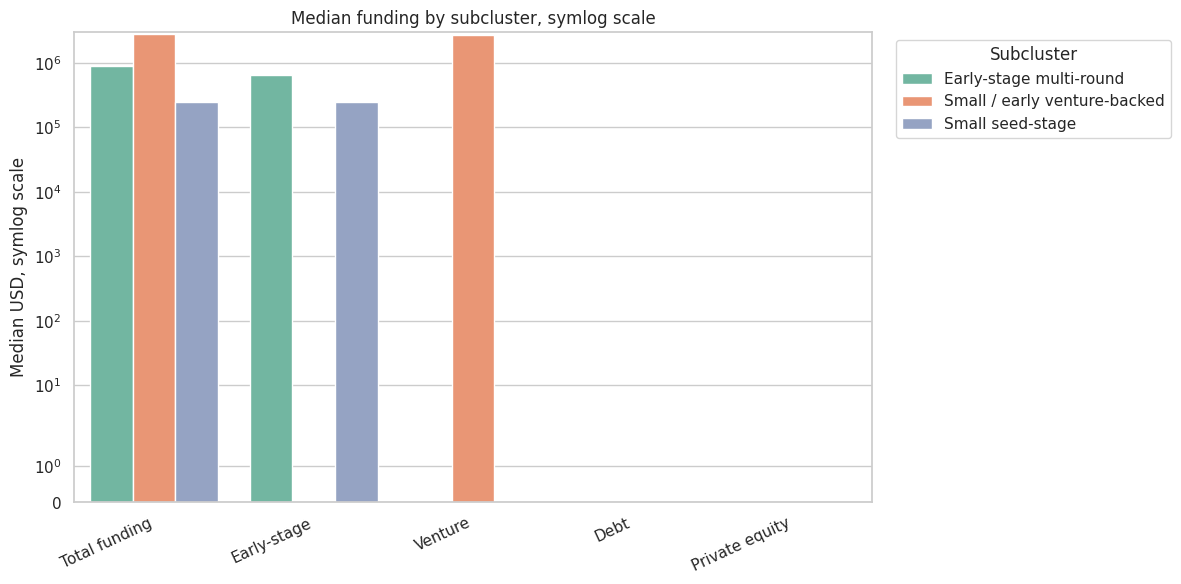

In [12]:
# ============================================================
# 11. Funding level visualization: median values
# ============================================================
funding_amount_cols = [
    'funding_total_usd',
    'early_stage_funding',
    'venture',
    'debt_financing',
    'private_equity'
]

funding_median_long = (
    median_profile[funding_amount_cols]
    .reset_index()
    .melt(id_vars='SubCluster_Name', var_name='Funding metric', value_name='Median USD')
)

funding_label_map = {
    'funding_total_usd': 'Total funding',
    'early_stage_funding': 'Early-stage',
    'venture': 'Venture',
    'debt_financing': 'Debt',
    'private_equity': 'Private equity'
}
funding_median_long['Funding metric'] = funding_median_long['Funding metric'].map(funding_label_map)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=funding_median_long,
    x='Funding metric',
    y='Median USD',
    hue='SubCluster_Name',
    palette='Set2'
)
ax.set_yscale('symlog')
ax.set_title('Median funding by subcluster, symlog scale')
ax.set_xlabel('')
ax.set_ylabel('Median USD, symlog scale')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Subcluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

,Early-stage,Venture,Debt,Private equity
SubCluster_Name,,,,
Early-stage multi-round,83.500,12.900,0.000,0.000
Small / early venture-backed,0.700,98.700,0.000,0.000
Small seed-stage,99.800,0.100,0.000,0.000


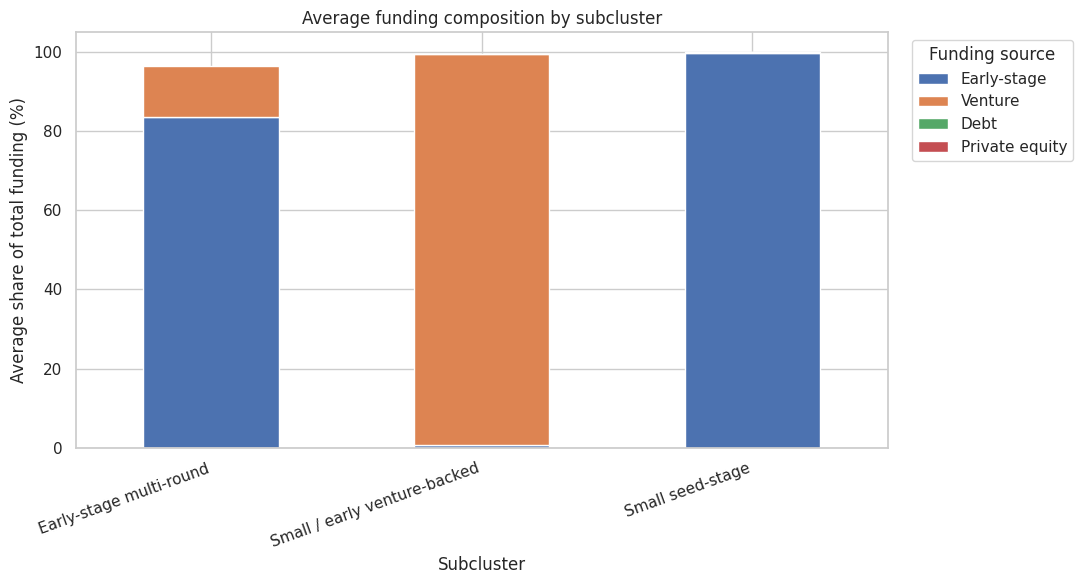

In [13]:
# ============================================================
# 12. Funding composition visualization: average ratios
# ============================================================
ratio_cols = [
    'early_stage_funding_ratio',
    'venture_ratio',
    'debt_financing_ratio',
    'private_equity_ratio'
]

composition = df_clustering_c0.groupby('SubCluster_Name')[ratio_cols].mean()
composition = composition.rename(columns={
    'early_stage_funding_ratio': 'Early-stage',
    'venture_ratio': 'Venture',
    'debt_financing_ratio': 'Debt',
    'private_equity_ratio': 'Private equity'
})

composition_pct = composition * 100
display(composition_pct.round(1))

ax = composition_pct.plot(kind='bar', stacked=True, figsize=(11, 6))
ax.set_title('Average funding composition by subcluster')
ax.set_xlabel('Subcluster')
ax.set_ylabel('Average share of total funding (%)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Funding source', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Mercados: onde cada subcluster está mais representado?

Para evitar comparar apenas contagens absolutas, usamos **market lift**:

> peso do mercado dentro do subcluster ÷ peso do mercado dentro do Cluster 0

Um lift acima de 1 significa que o mercado está sobre-representado naquele subcluster.

In [14]:
# ============================================================
# 13. Market distribution and market lift
# ============================================================
base_market_share = df_final_c0['market'].value_counts(normalize=True)

market_tables = {}
for cluster_name in sorted(df_final_c0['SubCluster_Name'].unique()):
    temp = df_final_c0[df_final_c0['SubCluster_Name'] == cluster_name]
    market_share = temp['market'].value_counts(normalize=True)
    market_count = temp['market'].value_counts()
    market_lift = (market_share / base_market_share).dropna().sort_values(ascending=False)
    market_lift = market_lift[market_count.reindex(market_lift.index).fillna(0) >= 20]
    
    out = pd.DataFrame({
        'market_share_pct': (market_share * 100).round(2),
        'count': market_count,
        'lift_vs_cluster0': market_lift.round(2)
    }).dropna().head(10)
    market_tables[cluster_name] = out
    
    print(f"\nTop over-represented markets — {cluster_name}")
    display(out)


Top over-represented markets — Early-stage multi-round


,market_share_pct,count,lift_vs_cluster0
market,,,
Advertising,2.360,97,1.040
Analytics,1.600,66,1.190
Apps,0.800,33,1.190
Big Data,0.830,34,2.030
Biotechnology,2.920,120,0.400
Clean Technology,0.950,39,0.410
Curated Web,4.230,174,1.020
Digital Media,0.610,25,2.120
E-Commerce,3.860,159,0.920



Top over-represented markets — Small / early venture-backed


,market_share_pct,count,lift_vs_cluster0
market,,,
Advertising,2.330,254,1.020
Analytics,1.220,133,0.900
Apps,0.180,20,0.270
Automotive,0.420,46,1.230
Big Data,0.220,24,0.540
Biotechnology,13.070,1425,1.810
Clean Technology,3.730,407,1.630
Cloud Computing,0.210,23,0.650
Consulting,1.270,139,1.410



Top over-represented markets — Small seed-stage


,market_share_pct,count,lift_vs_cluster0
market,,,
Advertising,2.170,197,0.950
Analytics,1.400,127,1.030
Android,0.320,29,1.330
Apps,1.210,110,1.790
Automotive,0.250,23,0.740
Big Data,0.440,40,1.080
Biotechnology,2.110,192,0.290
Bitcoin,0.280,25,1.660
Business Services,0.220,20,1.400


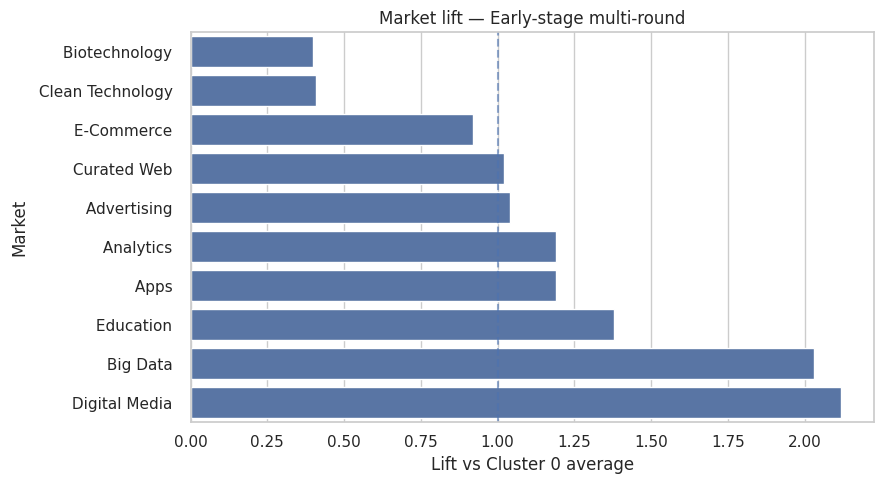

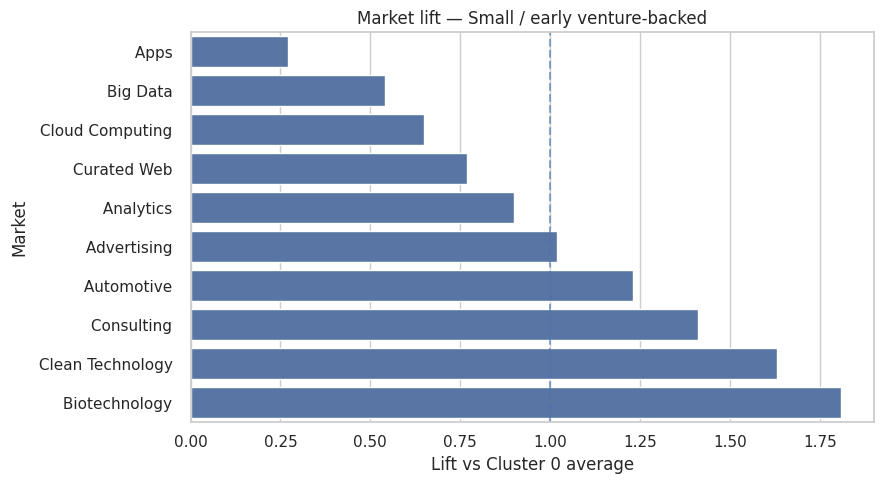

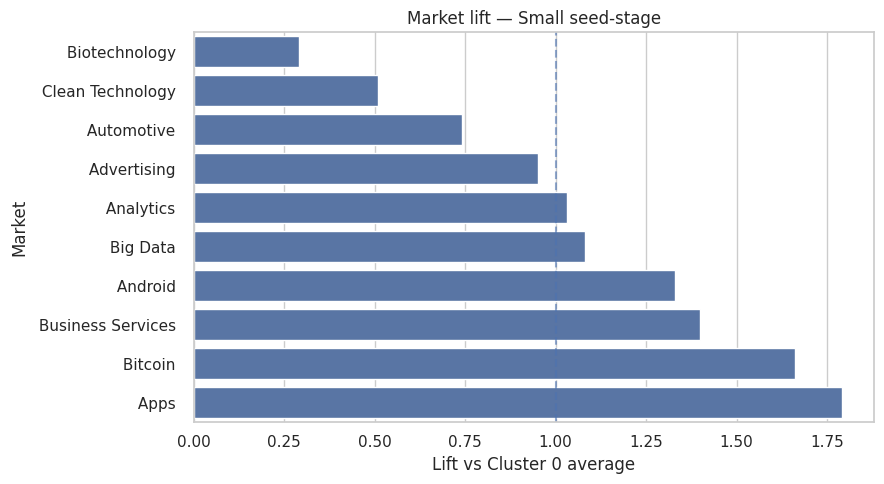

In [15]:
# One separate chart per subcluster for readability
for cluster_name, table in market_tables.items():
    plot_df = table.reset_index().rename(columns={'index': 'market'})
    plot_df = plot_df.sort_values('lift_vs_cluster0', ascending=True)
    
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=plot_df, x='lift_vs_cluster0', y='market', color='#4C72B0')
    ax.axvline(1, linestyle='--', alpha=0.6)
    ax.set_title(f'Market lift — {cluster_name}')
    ax.set_xlabel('Lift vs Cluster 0 average')
    ax.set_ylabel('Market')
    plt.tight_layout()
    plt.show()

## 10. Interpretação final dos subclusters

### Early-stage multi-round
Empresas ainda dominadas por funding inicial, mas com mais rondas e mais capital do que o seed-stage simples.  
Representa startups early-stage com alguma tração adicional.

### Small / early venture-backed
Empresas em que o financiamento dominante é venture capital, mas ainda dentro do Cluster 0.  
Isto significa que são VC-backed, mas mais pequenas/early-stage do que o cluster principal de Venture Capital.

### Small seed-stage
Empresas pequenas, geralmente com uma ronda, dominadas por seed/angel/grant.  
Representa o perfil mais inicial e mais leve em capital dentro do Cluster 0.

**Conclusão:** este sub-clustering é válido como análise complementar.  
Não substitui o clustering principal; serve para explicar a heterogeneidade interna do Cluster 0.

In [16]:
# ============================================================
# 14. Final summary table
# ============================================================
summary = pd.DataFrame(index=median_profile.index)
summary['n_startups'] = df_final_c0['SubCluster_Name'].value_counts().reindex(summary.index)
summary['pct_of_cluster0'] = summary['n_startups'] / len(df_final_c0) * 100
summary['median_total_funding_usd'] = median_profile['funding_total_usd']
summary['median_funding_rounds'] = median_profile['funding_rounds']
summary['median_stage_level'] = median_profile['stage_level']
summary['median_early_stage_ratio'] = median_profile['early_stage_funding_ratio']
summary['median_venture_ratio'] = median_profile['venture_ratio']
summary['pct_with_venture'] = nonzero_profile['venture']
summary['pct_with_early_stage'] = nonzero_profile['early_stage_funding']

summary = summary.sort_values('median_total_funding_usd', ascending=False)
display(summary.round(2))

,n_startups,pct_of_cluster0,median_total_funding_usd,median_funding_rounds,median_stage_level,median_early_stage_ratio,median_venture_ratio,pct_with_venture,pct_with_early_stage
SubCluster_Name,,,,,,,,,
Small / early venture-backed,10902,45.230,"2,840,500.000",1.000,0.000,0.000,1.000,100.000,4.420
Early-stage multi-round,4114,17.070,"900,000.000",2.000,0.000,1.000,0.000,23.750,98.660
Small seed-stage,9086,37.700,"250,000.000",1.000,0.000,1.000,0.000,0.140,99.800


In [17]:
# ============================================================
# 15. Export files
# ============================================================
# Final labelled dataset for Cluster 0
export_cols = info_columns + ['Cluster', 'SubCluster', 'SubCluster_Name'] + profile_cols
cluster0_export = pd.concat(
    [
        df_final_c0[info_columns + ['Cluster', 'SubCluster', 'SubCluster_Name']],
        df_clustering_c0[profile_cols]
    ],
    axis=1
)

cluster0_export.to_csv('cluster0_subclustered_explained.csv', index=False)

with pd.ExcelWriter('cluster0_subcluster_profiles.xlsx') as writer:
    k_eval_c0.to_excel(writer, sheet_name='k_evaluation', index=False)
    summary.to_excel(writer, sheet_name='summary')
    median_profile.to_excel(writer, sheet_name='median_profile')
    mean_profile.to_excel(writer, sheet_name='mean_profile')
    nonzero_profile.to_excel(writer, sheet_name='nonzero_pct')
    lift_display.to_excel(writer, sheet_name='feature_lift')
    for cluster_name, table in market_tables.items():
        safe_sheet = cluster_name.replace('/', '-').replace(' ', '_')[:31]
        table.to_excel(writer, sheet_name=safe_sheet)

print("Exported:")
print("- cluster0_subclustered_explained.csv")
print("- cluster0_subcluster_profiles.xlsx")

Exported:
- cluster0_subclustered_explained.csv
- cluster0_subcluster_profiles.xlsx
